In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [18]:
# GENERACIÓN DE DATOS
def lorenz_system(t, state, sigma=10.0, beta=8.0/3.0, rho=28.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

dt = 0.001
t_span = (0, 100)
t_eval = np.arange(t_span[0], t_span[1], dt)
initial_state = [-8.0, 8.0, 27.0]

# Resolvemos la EDO
sol = solve_ivp(lorenz_system, t_span, initial_state, t_eval=t_eval)
x_data = sol.y[0, :] # Medimos solo la variable 'x' para el teorema de Takens

In [ ]:
# MATRIZ DE HANKEL
print("Construyendo la matriz de Hankel...")
q = 100  # Número de retrasos temporales (filas)
m = len(x_data)
p = m - q + 1  # Número de columnas

H = np.zeros((q, p))
for i in range(q):
    H[i, :] = x_data[i:i+p]

print("Calculando SVD...")
U, S, VT = np.linalg.svd(H, full_matrices=False) #full_matrices=False reduce las dimensiones de U y Vt al mínimo para reconstruir X_delay (se queda con el rango) 

V = VT.T  # Trasponemos para que las columnas sean las trayectorias temporales ("eigen-time-delay coordinates")

Construyendo la matriz de Hankel...
Calculando SVD...


In [20]:
#MODELO HAVOK
r = 15  # Truncamiento. Lo cogí según el articulo original
V_r = V[:, :r]

#------------------------------------------------------------------------------------------------------------------------------
#Cada fila de V_r es un tiempo especifico y cada columna es una coordenada de retraso. 
#Si fijo la fila i, V_r[i, :] es el vector de coordenadas de retraso en el tiempo t_i (describe las coordenadas de la particula en ese instante)
#------------------------------------------------------------------------------------------------------------------------------

# Calculamos la derivada temporal de las coordenadas V usando diferencias centrales finitas
dV = np.zeros_like(V_r)
dV[1:-1, :] = (V_r[2:, :] - V_r[:-2, :]) / (2 * dt)  #desde el segundo hasta el penúltimo, para evitar los extremos

# Recortamos los extremos para evitar los ceros de las derivadas incompletas
V_trim = V_r[1:-1, :]
dV_trim = dV[1:-1, :]

# Separación de variables 
v_state = V_trim[:, :-1]      # v_state contiene las primeras r-1 variables/columnas (dinámica lineal)
v_forcing = V_trim[:, -1:]     # v_forcing contiene la ultima variable/columna r (forzamiento no lineal intermitente)

print(f"Forma de V_trim:", V_trim.shape)
print(f"Forma de v_state:", v_state.shape)
print(f"Forma de v_forcing:", v_forcing.shape)


Forma de V_trim: (99899, 15)
Forma de v_state: (99899, 14)
Forma de v_forcing: (99899, 1)


In [21]:
# Pegamos HORIZONTALMENTE. Xi tendrá dimensión (N x r)
Xi = np.hstack((v_state, v_forcing))  #Es literal V_trim pero conceptualmente distinta (matriz de regresion)
print(f"Forma de Xi:",Xi.shape)

# Queremos predecir las derivadas de los estados. Dimensión: N x (r-1)
dV_state = dV_trim[:, :-1]   #Quiero extraer la ultima columna como una fuerza externa
print(f"Forma de dV_state:",dV_state.shape)

# REGRESIÓN POR MÍNIMOS CUADRADOS
#OBJETIVO: dV_state_T (14,N) = M (14,15) * Xi_T (15,N). Es la forma normal de escribir laa cosas, 14 ecuaciones
#PROBLEMA: Python solo sabe resolver: Y = X * A donde A es lo que queremos obtener. YO EN REALIDAD QUERRÍA: Y = A * X

#Entonces, traspongo: dV_state_T (N,14) = Xi (N,15) * M_T (15,14) 

print("Calculando la regresión lineal...")
M_T, _, _, _ = np.linalg.lstsq(Xi, dV_state, rcond=None)

# Transponemos para obtener la forma [A | B] de dimensión (r-1) x (r)
M = M_T.T
print(f"Forma Modelo:",M.shape)

# CORTAMOS PARA SEPARAR EL SISTEMA
A = M[:, :-1]  # Matriz A (dinámica lineal): (r-1) x (r-1)
B = M[:, -1:]  # Vector B (forzamiento externo): (r-1) x 1

print(f"Forma de A: {A.shape}")        # Debería dar (14, 14)
print(f"Forma de B: {B.shape}")        # Debería dar (14, 1)

Forma de Xi: (99899, 15)
Forma de dV_state: (99899, 14)
Calculando la regresión lineal...
Forma Modelo: (14, 15)
Forma de A: (14, 14)
Forma de B: (14, 1)


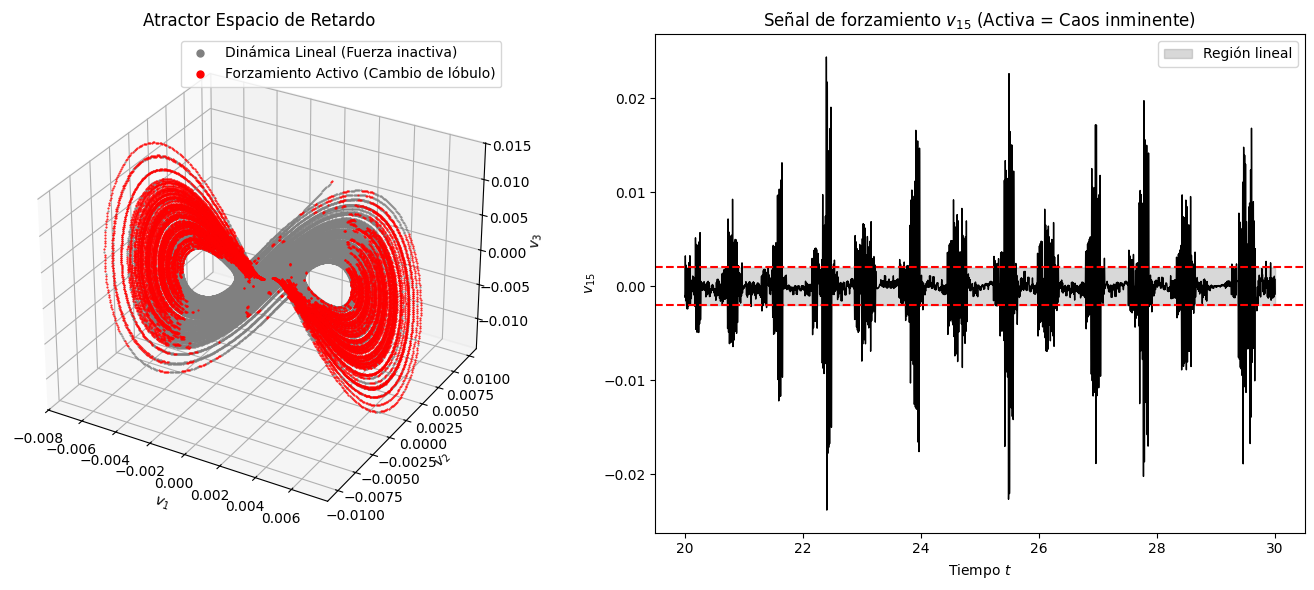

In [22]:
#Graficos
# Vamos a aislar las regiones donde la fuerza v_r es muy grande (predice caos)
vr_señal = v_forcing.flatten()  #Lo convierto en una lista de numeros
threshold = 0.002 # Umbral basado en el artículo

# Índices (instantes de tiempo) donde el forzamiento está activo (fuertemente no lineal) e inactivo
active_ind = np.abs(vr_señal) > threshold
inactive_ind = np.abs(vr_señal) <= threshold

plt.figure(figsize=(14, 6))

#----------------------------------------------------------------------------------------------
# Subplot 1: Atractor (en el espacio de retardo) 
ax1 = plt.subplot(1, 2, 1, projection='3d')

# Pintamos la parte gris (Dinámica estable)
ax1.plot(v_state[inactive_ind, 0], v_state[inactive_ind, 1], v_state[inactive_ind, 2], 
         '.', color='gray', markersize=1, label='Dinámica Lineal (Fuerza inactiva)')

ax1.plot(v_state[active_ind, 0], v_state[active_ind, 1], v_state[active_ind, 2], 
         '.', color='red', markersize=1, label='Forzamiento Activo (Cambio de lóbulo)')

ax1.set_title("Atractor Espacio de Retardo")
ax1.set_xlabel("$v_1$")
ax1.set_ylabel("$v_2$")
ax1.set_zlabel("$v_3$")
ax1.legend(markerscale=10)

#--------------------------------------------------------------------------------------------------
# Subplot 2: Señal de forzamiento en el tiempo (zoom a un fragmento específico para que se vea algo decente)
ax2 = plt.subplot(1, 2, 2)
zoom_start, zoom_end = 20000, 30000 # Zoom de índices para ver los picos
t_zoom = t_eval[1:-1][zoom_start:zoom_end]  #Quito el instante 20000y 30000 xq no puedo calcular derivadas al principio y final
vr_zoom = vr_señal[zoom_start:zoom_end]

ax2.plot(t_zoom, vr_zoom, color='black', linewidth=1)

ax2.axhline(threshold, color='red', linestyle='--')
ax2.axhline(-threshold, color='red', linestyle='--')
ax2.fill_between(t_zoom, -threshold, threshold, color='gray', alpha=0.3, label='Región lineal')

ax2.set_title(f"Señal de forzamiento $v_{{{r}}}$ (Activa = Caos inminente)")
ax2.set_xlabel("Tiempo $t$")
ax2.set_ylabel(f"$v_{{{r}}}$")
ax2.legend()

plt.tight_layout()
plt.show()